In [17]:
import re
import string
import pandas as pd
import numpy as np
from tqdm import tqdm
import inflect
import spacy
from nltk.corpus import stopwords
import contractions
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv("DataFrameWithLanguageCol.csv", usecols=["Review", "Rating", "Language"])

df = df[df["Language"] == "en"].copy()
df.drop(columns=["Language"], inplace=True)

print(f"DataFrame shape after filtering to English reviews: {df.shape}" , end="\n\n")
print("Value counts for 'Rating' column:")
print(df['Rating'].value_counts(), end="\n\n")
print(f"DataFrame Columns ({len(df.columns)} total):\n- " + "\n- ".join(df.columns) , end="\n\n")
print(f"Duplicate reviews: {df['Review'].duplicated().sum()} / {len(df)} ({df['Review'].duplicated().sum() / len(df):.2%})")

DataFrame shape after filtering to English reviews: (3586509, 2)

Value counts for 'Rating' column:
Rating
1    1794975
2    1791534
Name: count, dtype: int64

DataFrame Columns (2 total):
- Review
- Rating

Duplicate reviews: 0 / 3586509 (0.00%)


In [57]:
# Load SpaCy model with minimal components
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Initialize stopwords, preserving negations
stop_words = set(stopwords.words("english")) - {"not", "no", "nor", "n't"}

# Inflect engine for number-to-word conversion
p = inflect.engine()

def remove_punctuation_except(text, keep="!?"):
    """Remove all punctuation except specified characters."""
    return "".join(char for char in text if char.isalnum() or char.isspace() or char in keep)

def convert_nums(text, failed_indices=None, current_idx=None):
    """Convert numeric strings to their word equivalents.
    Record the index of text if exception happens."""
    def replacer(match):
        try:
            num_str = match.group()
            if num_str.endswith('.') and num_str.count('.') == 1:
                num_str = num_str.rstrip('.')
            if '.' in num_str:
                int_part, decimal_part = num_str.split('.', 1)
                int_words = p.number_to_words(int_part, andword='') if int_part else ''
                decimal_words = ' '.join(
                    p.number_to_words(d) for d in decimal_part if d.isdigit()
                ) if decimal_part else ''
                return f"{int_words} point {decimal_words}".strip()
            return p.number_to_words(num_str, andword='')
        except Exception:
            print(f"[Warning] Failed to convert number: '{match.group()}'")
            if failed_indices is not None and current_idx is not None:
                failed_indices.add(current_idx)  # record failure index
            return match.group()
    return re.sub(r'\d+(\.\d+)?', replacer, text)

def preprocess_raw_text(text, failed_indices=None, idx=None):
    """Preprocess raw text (expand contractions, remove punctuation except !?, convert nums, normalize whitespace)."""
    text = contractions.fix(text)                                              # Expand contractions
    text = text.strip().lower()                                                # Lowercase and trim
    text = remove_punctuation_except(text, keep="!?")                          # Remove unwanted punctuation
    text = convert_nums(text, failed_indices=failed_indices, current_idx=idx)  # Convert numbers to words
    text = " ".join(text.split())                                              # Normalize whitespace
    return text

def preprocess_batch(texts):
    """Apply full preprocessing and lemmatization to a list of text entries."""
    failed_indices = set()  # store indices of texts that raised exception during number conversion

    # Step 1: preprocess raw texts (expand contractions, punctuation removal, number conversion)
    cleaned_texts = [
        preprocess_raw_text(text, failed_indices=failed_indices, idx=i)
        for i, text in enumerate(tqdm(texts, desc="Preprocessing Raw Texts"))
    ]

    # Step 2: run SpaCy pipeline once on cleaned texts to get lemmas and remove stopwords
    cleaned_lemmas = []
    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=1000), total=len(cleaned_texts), desc="Lemmatizing"):
        # Lemmatize and remove stopwords (except negations)
        lemmas = [
            token.lemma_ for token in doc
            if token.text not in stop_words and not token.is_punct and not token.is_space
        ]
        cleaned_lemmas.append(" ".join(lemmas))

    return cleaned_lemmas, failed_indices


def addTextFeatures(df, textCol="Review", failedIndices=None, index_map=None):
    """
    Add columns to DataFrame:
      - failedNumberConversion: bool indicating if index is in failedIndices
      - sentenceLength: number of words in the textCol
      - numExclamations: count of '?' and '!' in textCol

    Parameters:
      df (pd.DataFrame): DataFrame to add columns to
      textCol (str): name of the text column
      failedIndices (set or list): indices where number conversion failed (relative to input list)
      index_map (list or Series): maps positions in the failedIndices to actual DataFrame indices

    Returns:
      pd.DataFrame: DataFrame with new columns added
    """
    if failedIndices is None:
        failedIndices = set()

    # Map failed indices to actual df indices if index_map is given
    if index_map is not None:
        actual_failed_indices = [index_map[i] for i in failedIndices]
    else:
        actual_failed_indices = failedIndices

    df["failedNumberConversion"] = 0
    df.loc[actual_failed_indices, "failedNumberConversion"] = 1
    
    # Create new column with sentence length
    df["sentenceLength"] = df[textCol].apply(lambda x: len(str(x).split()))
    
    # Count the number of exclamation and question marks in each original review to capture emphatic or interrogative tone
    df["numExclamations"] = df[textCol].apply(lambda x: sum(x.count(c) for c in ["?", "!"]))
    
    return df


<h3>Preprocessing pipeline validation on a random small sample</h3>

In [58]:
# Create a sample of 1000 rows from the original DataFrame (random sample, without replacement)
sample_df = df.sample(n=100000, random_state=42).copy()

texts_sample = sample_df["Review"].tolist()

# Run preprocessing on sample texts
processed_texts_sample, failed_indices_sample = preprocess_batch(texts_sample)
sample_df["processedReview"] = processed_texts_sample

# Use the addTextFeatures function to add the extra features
sample_df = addTextFeatures(
    sample_df, 
    textCol="processedReview", 
    failedIndices=failed_indices_sample, 
    index_map=sample_df.index.to_list()
)

print("\n" * 3)
print(f"Sample preprocessing done. Sample shape: {sample_df.shape}" , end="\n\n")

expected_cols = ["Review", "Rating", "processedReview", "failedNumberConversion", "sentenceLength", "numExclamations"]
if list(sample_df.columns) == expected_cols:
    print("Everything is fine: DataFrame columns are as expected." , end="\n\n")
else:
    print("Warning: DataFrame columns do not match the expected list." , end="\n\n")

print(f"Number of failed number conversions in sample: {len(failed_indices_sample)}")
print(f"Number of rows marked as failedNumberConversion: {sample_df['failedNumberConversion'].sum()}" , end="\n\n")

print(f"Number of empty entries in 'processedReview': {sample_df['processedReview'].isna().sum()}", end="\n\n")

print("Example processed reviews:")
for review in sample_df['processedReview'].head(5):
    print(review)
print("\n\n")

print("Sentence length stats:")
print(sample_df["sentenceLength"].describe(), end="\n\n")

print("Number of exclamations stats:")
print(sample_df["numExclamations"].describe())

Preprocessing Raw Texts:   5%|▍         | 4933/100000 [00:00<00:15, 6234.05it/s]

[Warning] Failed to convert number: '30000123456775432211234567754287878784343465789865321125666'


Preprocessing Raw Texts:  28%|██▊       | 27945/100000 [00:04<00:10, 6554.95it/s]

[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'
[Warning] Failed to convert number: '999999999999999999999999999999999999999999999'


Preprocessing Raw Texts:  50%|████▉     | 49681/100000 [00:08<00:08, 6269.35it/s]

[Warning] Failed to convert number: '243143575819968234503520120080199682021430340'


Lemmatizing: 100%|██████████| 100000/100000 [07:24<00:00, 224.78it/s]






Sample preprocessing done. Sample shape: (100000, 6)

Everything is fine: DataFrame columns are as expected.

Number of failed number conversions in sample: 3
Number of rows marked as failedNumberConversion: 3

Number of empty entries in 'processedReview': 0

Example processed reviews:
buy never get say two camera pay box ship one call hold half hour finally hang ten warn
not much miss usually big fiftys sci fi buff could resist great title cover art right?it decent story well do really not much nothing really creative far scare special effect plastic skull roll around floor probably would play well twelve hour episode night gallery reference purpose fiftys horror prefer house haunted hill tingler film scream skull not bad uneventful lack real scare creativityone thing note good time version decent transfer sound hiss crackle goodtime gt logo stay bottom corner screen entire picture guess goodtime always lame
two kind pain thing never able comprehend even live one hundred example s

In [59]:
texts = df["Review"].tolist()

# Run preprocessing on full dataset texts
processed_texts, failed_indices = preprocess_batch(texts)
df["processedReview"] = processed_texts

# Create index_map for the full df (list of actual df indices)
index_map = df.index.to_list()

# Add text features with the correct index_map
df = addTextFeatures(
    df,
    textCol="processedReview",
    failedIndices=failed_indices,
    index_map=index_map
)

df.to_csv("preprocessedDataFrame.csv", index=False)
print(f"DataFrame successfully saved.")

Preprocessing Raw Texts:   1%|          | 29467/3586509 [00:04<07:34, 7821.43it/s]

[Warning] Failed to convert number: '10000000000000000000000000000000000000'


Preprocessing Raw Texts:   1%|          | 38764/3586509 [00:05<07:11, 8230.82it/s]

[Warning] Failed to convert number: '999999999999999999999999999999999999999'


Preprocessing Raw Texts:   3%|▎         | 116771/3586509 [00:16<08:23, 6890.76it/s]

...

[Warning] Failed to convert number: '999999999999999999999999999999999999999999999999'


Preprocessing Raw Texts:  97%|█████████▋| 3487616/3586509 [07:15<00:11, 8366.24it/s]

[Warning] Failed to convert number: '9999999999999999999999999999999999999999999999999'


Lemmatizing: 100%|██████████| 3586509/3586509 [3:42:19<00:00, 268.86it/s]  


DataFrame successfully saved.


In [ ]:
print(f"preprocessing done. DataFrame shape: {df.shape}" , end="\n\n")

expected_cols = ["Review", "Rating", "processedReview", "failedNumberConversion", "sentenceLength", "numExclamations"]
if list(df.columns) == expected_cols:
    print("Everything is fine: DataFrame columns are as expected." , end="\n\n")
else:
    print("Warning: DataFrame columns do not match the expected list." , end="\n\n")

print(f"Number of failed number conversions : {len(failed_indices)}")
print(f"Number of rows marked as failedNumberConversion: {df['failedNumberConversion'].sum()}" , end="\n\n")

print(f"Number of empty entries in 'processedReview': {df['processedReview'].isna().sum()}", end="\n\n")

print("Example processed reviews:")
for review in df['processedReview'].head(5):
    print(review)
print("\n\n")

print("Sentence length stats:")
print(df["sentenceLength"].describe(), end="\n\n")

print("Number of exclamations stats:")
print(df["numExclamations"].describe())

Sample preprocessing done. Sample shape: (3586509, 6)

Everything is fine: DataFrame columns are as expected.

Number of failed number conversions in sample: 60
Number of rows marked as failedNumberConversion: 60

Number of empty entries in 'processedReview': 0

Example processed reviews:
stun even nongamer sound track beautiful paint senery mind well would recomend even people hate vid game music play game chrono cross game ever play good music back away crude keyboarding take fresher step grate guitar soulful orchestra would impress anyone care listen
good soundtrack ever anything read lot review say good game soundtrack figure would write review disagree bit opinino yasunori mitsudas ultimate masterpiece music timeless listen year beauty simply refuse fadethe price tag pretty staggering must say go buy cd much money one feel would worth every penny
amazing soundtrack favorite music time hand intense sadness prisoner fate mean play game hope distant promise girl steal star important 

In [11]:
df = pd.read_csv("preprocessedDataFrame.csv")
clean_df = df.loc[df['processedReview'].notna(), ['processedReview', 'Rating']].copy()
print(clean_df.info())  # Just to verify

<class 'pandas.core.frame.DataFrame'>
Index: 3586507 entries, 0 to 3586508
Data columns (total 2 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   processedReview  object
 1   Rating           int64 
dtypes: int64(1), object(1)
memory usage: 82.1+ MB
None


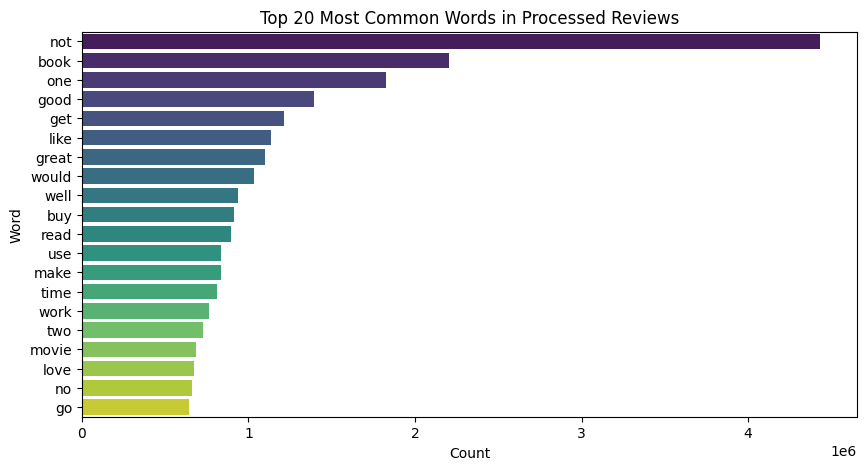

In [12]:
all_words = []
for review in tqdm(clean_df['processedReview'], desc="Collecting words"):
    all_words.extend(review.split())

common_words = Counter(all_words).most_common(20)
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=common_words_df, palette='viridis')
plt.title('Top 20 Most Common Words in Processed Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()


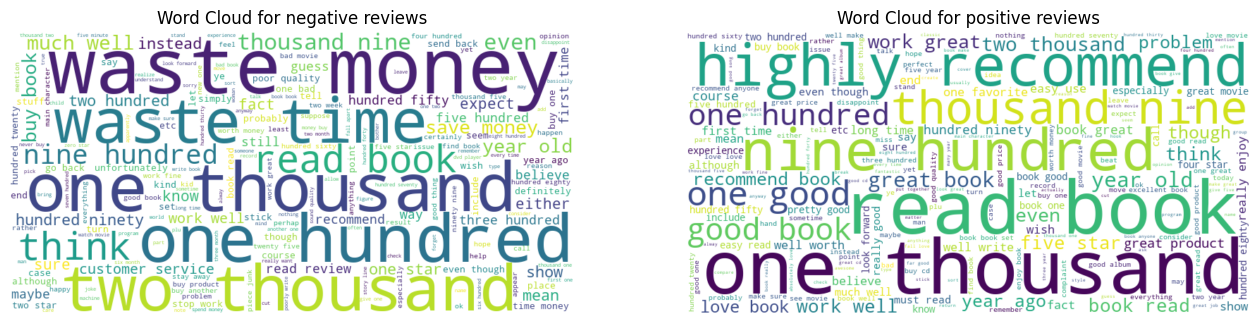

In [19]:
# Filter the DataFrame by rating
reviews_rating_1 = clean_df[clean_df['Rating'] == 1]['processedReview'].str.cat(sep=' ')
reviews_rating_2 = clean_df[clean_df['Rating'] == 2]['processedReview'].str.cat(sep=' ')

# Generate word clouds
wc1 = WordCloud(width=800, height=400, background_color='white').generate(reviews_rating_1)
wc2 = WordCloud(width=800, height=400, background_color='white').generate(reviews_rating_2)

# Plot side by side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc1, interpolation='bilinear')
plt.title('Word Cloud for negative reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc2, interpolation='bilinear')
plt.title('Word Cloud for positive reviews')
plt.axis('off')

plt.show()

<p>Fares Alfares</p>